# CV EDA Notebook

Notebook ini khusus EDA untuk problem Computer Vision classification di Kaggle.
Tidak ada training, tidak ada pretrained model, tidak ada widget.

Pola pakai:

```text
parameter cell -> mesin EDA -> preview / scorecard / rekomendasi
```

Tujuan utama:

- ngerti bentuk dataset dulu sebelum modelling
- aman untuk `folder_class`, `csv_path`, dan `csv_pixels`
- kasih rekomendasi lego untuk notebook training `cv_lego_god.ipynb`
- khusus membantu keputusan: loader, segmentasi, preprocessing, metric/loss, dan submit sanity

In [19]:
# ============================================================
# 0. GLOBAL SETUP
# ============================================================

print("EDA FIRST: baca data, cek label, cek gambar, baru modelling.")
print("BACA METRIC KAGGLE DULU. EDA ini bantu rekomendasi, bukan pengganti metric competition.")

import os
import re
import math
import json
import random
import warnings
from pathlib import Path
from collections import Counter, defaultdict

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps, UnidentifiedImageError

try:
    import cv2
    CV2_AVAILABLE = True
except Exception as e:
    cv2 = None
    CV2_AVAILABLE = False
    print("cv2 unavailable. OpenCV-specific EDA will use fallback:", repr(e))

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

STATE = {
    "train_df": None,
    "test_df": None,
    "sample_submission": None,
    "classes": None,
    "num_classes": None,
    "label_counts": None,
    "image_stats": None,
    "findings": {},
    "recommendations": [],
}

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

def step(msg):
    print("\n" + "=" * 100)
    print(msg)
    print("=" * 100)

def show_grid(images, titles=None, n=16, figsize=(12, 12), cmap=None):
    images = list(images)[:n]
    if len(images) == 0:
        print("No images to show.")
        return
    cols = min(4, len(images))
    rows = math.ceil(len(images) / cols)
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        arr = np.asarray(img)
        if arr.ndim == 2:
            plt.imshow(arr, cmap=cmap or "gray")
        else:
            plt.imshow(arr)
        if titles is not None:
            plt.title(str(titles[i])[:70], fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def plot_bar(series, title="", figsize=(10, 4), rotation=45):
    s = pd.Series(series)
    plt.figure(figsize=figsize)
    s.plot(kind="bar")
    plt.title(title)
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

def describe_options(title, options):
    print("\n" + title)
    for name, desc in options.items():
        print(f"- {name}: {desc}")

def add_reco(text):
    if text not in STATE["recommendations"]:
        STATE["recommendations"].append(text)

EDA FIRST: baca data, cek label, cek gambar, baru modelling.
BACA METRIC KAGGLE DULU. EDA ini bantu rekomendasi, bukan pengganti metric competition.


In [22]:
import os
DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"
files = sorted(os.listdir(f"{DATA_ROOT}/images"))[:5]
print(files)  # liat: id_0001.png? id_1.png?
import pandas as pd
print(pd.read_csv(f"{DATA_ROOT}/train.csv").head())
print(pd.read_csv(f"{DATA_ROOT}/sample_submission.csv").head())

['id_000D.png', 'id_00CR.png', 'id_00H2.png', 'id_00LN.png', 'id_00N1.png']
  image_id  char
0  id_30U7  9610
1  id_5OK6  9041
2  id_EKC8  4202
3  id_GYIW  3201
4  id_213Y  1602
  image_id image_pair
0  id_DCBL    id_AAAA
1  id_YUKN    id_AAAA
2  id_25WM    id_AAAA
3  id_6ESM    id_AAAA
4  id_L51F    id_AAAA


## 1A. Parameter: Loader Manual

In [9]:
# # ============================================================
# # 1A. LOADER PARAMETERS
# # ============================================================

# # Pilih manual. Untuk Digit Recognizer pakai "csv_pixels".
# LOADER_MODE = "folder_class"  # "folder_class" / "csv_path" / "csv_pixels"

# # Common paths. Leave None to auto-find train/test/sample by filename.
# TRAIN_CSV = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv"
# TEST_CSV = None
# SAMPLE_SUBMISSION_CSV = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv"

# # csv_path mode: CSV punya kolom nama/path gambar + label.
# IMAGE_COL = None
# LABEL_COL = "label"
# ID_COL = None
# IMAGE_ROOT = None

# # folder_class mode: train/class_name/*.jpg, test/*.jpg.
# TRAIN_DIR = None
# TEST_DIR = None

# # csv_pixels mode: semua pixel ada di kolom CSV, contoh MNIST pixel0..pixel783.
# PIXEL_COLS = None
# PIXEL_PREFIX = "pixel"
# PIXEL_SHAPE = (28, 28, 1)

# PREVIEW_ROWS = 16

# print("actually works")

actually works


In [24]:
# ============================================================
# 1A. LOADER PARAMETERS
# ============================================================
LOADER_MODE = "csv_path"

DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"
# kalau path-nya yang panjang, ganti pake yang muncul di error lo:
# DATA_ROOT = "/kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data"

TRAIN_CSV = f"{DATA_ROOT}/train.csv"
TEST_CSV = f"{DATA_ROOT}/sample_submission.csv"   # test pake sample_submission
SAMPLE_SUBMISSION_CSV = f"{DATA_ROOT}/sample_submission.csv"

IMAGE_COL = "image_id"
LABEL_COL = "char"
ID_COL = "image_id"
IMAGE_ROOT = f"{DATA_ROOT}/images"

TRAIN_DIR = None
TEST_DIR = None
PIXEL_COLS = None
PIXEL_PREFIX = "pixel"
PIXEL_SHAPE = (28, 28, 1)
PREVIEW_ROWS = 16

## 1B. Mesin: Load Data

In [25]:
# ============================================================
# 1B. LOAD DATA MACHINE
# ============================================================

def input_roots():
    roots = []
    if Path("/kaggle/input").exists():
        roots.append(Path("/kaggle/input"))
    roots.append(Path("."))
    return roots

def find_named_csv(keyword):
    candidates = []
    for root in input_roots():
        candidates.extend(root.glob(f"**/*{keyword}*.csv"))
    candidates = sorted(set(candidates), key=lambda p: len(str(p)))
    return candidates[0] if candidates else None

def list_image_dirs(limit=25):
    dirs = []
    for root in input_roots():
        for p in root.glob("**/*"):
            if p.is_dir():
                try:
                    has_img = any(child.is_file() and child.suffix.lower() in IMAGE_EXTS for child in p.iterdir())
                    if has_img:
                        dirs.append(p)
                except Exception:
                    pass
    return dirs[:limit]

def column_candidates(df):
    cols = list(df.columns)
    id_cands = [
        c for c in cols
        if str(c).lower() in ["id", "image_id", "imageid", "file_id", "filename", "file", "path", "image"]
        or "id" in str(c).lower()
    ]
    path_cands = []
    for c in cols:
        s = df[c].dropna().astype(str).head(80)
        if len(s) and s.map(lambda x: Path(x).suffix.lower() in IMAGE_EXTS or "/" in x or "\\" in x).mean() > 0.3:
            path_cands.append(c)
    label_cands = [c for c in cols if str(c).lower() in ["label", "target", "class", "category", "species", "y"]]
    pixel_cands = [c for c in cols if str(c).lower().startswith("pixel")]
    return id_cands, path_cands, label_cands, pixel_cands

_IMAGE_INDEX = None

def build_image_index():
    global _IMAGE_INDEX
    if _IMAGE_INDEX is not None:
        return _IMAGE_INDEX
    idx = {}
    for base in input_roots():
        try:
            for p in base.rglob("*"):
                if p.is_file() and p.suffix.lower() in IMAGE_EXTS:
                    idx.setdefault(p.name, str(p))
                    idx.setdefault(p.stem, str(p))
        except Exception:
            pass
    _IMAGE_INDEX = idx
    print(f"Image index built: {len(idx)} lookup keys")
    return idx

def resolve_path(x, root=None):
    if pd.isna(x):
        return None
    raw = str(x)
    p = Path(raw)
    if p.exists():
        return str(p)
    if root is not None:
        rp = Path(root) / raw
        if rp.exists():
            return str(rp)
    for base in input_roots():
        rp = base / raw
        if rp.exists():
            return str(rp)
    idx = build_image_index()
    hit = idx.get(Path(raw).name) or idx.get(Path(raw).stem)
    return hit if hit is not None else raw

def read_image_rgb(path):
    try:
        img = Image.open(path).convert("RGB")
        return np.asarray(img)
    except Exception as e:
        raise RuntimeError(f"Could not read image: {path} | {repr(e)}")

def pixels_to_image(row, pixel_cols, shape):
    arr = row[pixel_cols].to_numpy(dtype=np.float32)
    arr = arr.reshape(shape)
    if arr.max() <= 1.0:
        arr = arr * 255.0
    arr = np.clip(arr, 0, 255).astype(np.uint8)
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    elif arr.shape[-1] == 1:
        arr = np.repeat(arr, 3, axis=-1)
    return arr

def load_csvs():
    train_csv = Path(TRAIN_CSV) if TRAIN_CSV else find_named_csv("train")
    test_csv = Path(TEST_CSV) if TEST_CSV else find_named_csv("test")
    sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
    if train_csv is None or test_csv is None:
        raise FileNotFoundError("Could not find train/test csv. Set TRAIN_CSV and TEST_CSV manually.")
    train_df = pd.read_csv(train_csv)
    test_df = pd.read_csv(test_csv)
    sample = pd.read_csv(sample_csv) if sample_csv is not None else None
    print("TRAIN_CSV:", train_csv)
    print("TEST_CSV :", test_csv)
    print("SAMPLE   :", sample_csv)
    print("train/test/sample shapes:", train_df.shape, test_df.shape, None if sample is None else sample.shape)
    return train_df, test_df, sample

def infer_test_ids(test_df, sample):
    if ID_COL and ID_COL in test_df.columns:
        return test_df[ID_COL]
    if sample is not None and len(sample) == len(test_df):
        return sample.iloc[:, 0].values
    return np.arange(len(test_df))

def load_dataset():
    step("Step 1/9: Loading data")
    mode = LOADER_MODE
    sample = None

    if mode == "csv_path":
        train_df, test_df, sample = load_csvs()
        id_cands, path_cands, label_cands, pixel_cands = column_candidates(train_df)
        print("Candidate ID columns   :", id_cands)
        print("Candidate image columns:", path_cands)
        print("Candidate label columns:", label_cands)
        if IMAGE_COL is None or LABEL_COL is None:
            raise ValueError("Set IMAGE_COL and LABEL_COL manually in Step 1A, then rerun Step 1B.")
        train_df = train_df.copy()
        test_df = test_df.copy()
        train_df["_image_path"] = train_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
        test_df["_image_path"] = test_df[IMAGE_COL].map(lambda x: resolve_path(x, IMAGE_ROOT))
        train_df["_label"] = train_df[LABEL_COL]
        train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
        test_df["_id"] = infer_test_ids(test_df, sample)
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))

    elif mode == "folder_class":
        sample_csv = Path(SAMPLE_SUBMISSION_CSV) if SAMPLE_SUBMISSION_CSV else find_named_csv("sample")
        sample = pd.read_csv(sample_csv) if sample_csv is not None else None
        if TRAIN_DIR is None or TEST_DIR is None:
            print("Image folders found:")
            for d in list_image_dirs():
                print("-", d)
            raise ValueError("Set TRAIN_DIR and TEST_DIR manually in Step 1A, then rerun Step 1B.")
        rows = []
        for class_dir in sorted(Path(TRAIN_DIR).iterdir()):
            if class_dir.is_dir():
                for p in sorted(class_dir.rglob("*")):
                    if p.suffix.lower() in IMAGE_EXTS:
                        rows.append({"_image_path": str(p), "_label": class_dir.name, "_id": p.stem})
        train_df = pd.DataFrame(rows)
        test_rows = [{"_image_path": str(p), "_id": p.stem} for p in sorted(Path(TEST_DIR).rglob("*")) if p.suffix.lower() in IMAGE_EXTS]
        test_df = pd.DataFrame(test_rows)
        if sample is not None and len(sample) == len(test_df):
            # Keep sample order visible for sanity, but file paths remain sorted by folder.
            pass
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))

    elif mode == "csv_pixels":
        train_df, test_df, sample = load_csvs()
        if LABEL_COL is None or PIXEL_SHAPE is None:
            raise ValueError("Set LABEL_COL and PIXEL_SHAPE manually for csv_pixels.")
        if PIXEL_COLS is not None:
            pixel_cols = list(PIXEL_COLS)
        elif PIXEL_PREFIX is not None:
            pixel_cols = [c for c in train_df.columns if str(c).startswith(PIXEL_PREFIX)]
        else:
            skip = {LABEL_COL}
            if ID_COL:
                skip.add(ID_COL)
            pixel_cols = [c for c in train_df.columns if c not in skip and pd.api.types.is_numeric_dtype(train_df[c])]
        if not pixel_cols:
            raise ValueError("No pixel columns found. Set PIXEL_COLS or PIXEL_PREFIX.")
        expected_pixels = int(np.prod(PIXEL_SHAPE))
        if len(pixel_cols) != expected_pixels:
            print(f"WARNING: pixel column count {len(pixel_cols)} != PIXEL_SHAPE product {expected_pixels}")
        train_df = train_df.copy()
        test_df = test_df.copy()
        train_df["_pixel_cols"] = [pixel_cols] * len(train_df)
        test_df["_pixel_cols"] = [pixel_cols] * len(test_df)
        train_df["_label"] = train_df[LABEL_COL]
        train_df["_id"] = train_df[ID_COL] if ID_COL and ID_COL in train_df.columns else np.arange(len(train_df))
        test_df["_id"] = infer_test_ids(test_df, sample)
        train_df["_orig_index"] = np.arange(len(train_df))
        test_df["_orig_index"] = np.arange(len(test_df))
        add_reco("Use SEGMENT_BLOCK = 'none' for csv_pixels / tiny clean images.")
    else:
        raise ValueError(f"Unknown LOADER_MODE: {mode}")

    classes = sorted(train_df["_label"].astype(str).unique().tolist())
    label_counts = train_df["_label"].astype(str).value_counts()

    STATE["train_df"] = train_df.reset_index(drop=True)
    STATE["test_df"] = test_df.reset_index(drop=True)
    STATE["sample_submission"] = sample
    STATE["classes"] = classes
    STATE["num_classes"] = len(classes)
    STATE["label_counts"] = label_counts

    print("LOADER_MODE:", LOADER_MODE)
    print("num_classes:", STATE["num_classes"])
    print("classes:", classes[:30], "..." if len(classes) > 30 else "")
    print("\nTrain preview:")
    display(STATE["train_df"].head(3))
    print("\nTest preview:")
    display(STATE["test_df"].head(3))
    if sample is not None:
        print("\nSample submission preview:")
        display(sample.head(3))

def get_raw_image(df, idx):
    row = df.iloc[idx]
    if LOADER_MODE == "csv_pixels":
        return pixels_to_image(row, row["_pixel_cols"], PIXEL_SHAPE)
    return read_image_rgb(row["_image_path"])

load_dataset()


Step 1/9: Loading data
TRAIN_CSV: /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/train.csv
TEST_CSV : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
SAMPLE   : /kaggle/input/competitions/seleksi-gemastik-2026-problem-2/data/sample_submission.csv
train/test/sample shapes: (500, 2) (500, 2) (500, 2)
Candidate ID columns   : ['image_id']
Candidate image columns: []
Candidate label columns: []
Image index built: 12000 lookup keys
LOADER_MODE: csv_path
num_classes: 500
classes: ['1011', '1016', '1045', '1061', '110', '1128', '114', '1141', '1168', '1216', '122', '1231', '1276', '1303', '131', '1345', '1387', '1390', '1404', '1405', '1408', '144', '1482', '1510', '1529', '1567', '1571', '1581', '1602', '1639'] ...

Train preview:


,image_id,char,_image_path,_label,_id,_orig_index
0,id_30U7,9610,/kaggle/input/competitions/seleksi-gemastik-20...,9610,id_30U7,0
1,id_5OK6,9041,/kaggle/input/competitions/seleksi-gemastik-20...,9041,id_5OK6,1
2,id_EKC8,4202,/kaggle/input/competitions/seleksi-gemastik-20...,4202,id_EKC8,2



Test preview:


,image_id,image_pair,_image_path,_id,_orig_index
0,id_DCBL,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,id_DCBL,0
1,id_YUKN,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,id_YUKN,1
2,id_25WM,id_AAAA,/kaggle/input/competitions/seleksi-gemastik-20...,id_25WM,2



Sample submission preview:


,image_id,image_pair
0,id_DCBL,id_AAAA
1,id_YUKN,id_AAAA
2,id_25WM,id_AAAA


## 2. Mesin: Schema EDA

In [26]:
# ============================================================
# 2. SCHEMA EDA MACHINE
# ============================================================

def schema_eda():
    step("Step 2/9: Schema EDA")
    train_df = STATE["train_df"]
    test_df = STATE["test_df"]
    sample = STATE["sample_submission"]
    assert train_df is not None, "Run Step 1B first."

    original_train_cols = [c for c in train_df.columns if not str(c).startswith("_")]
    original_test_cols = [c for c in test_df.columns if not str(c).startswith("_")]
    print("Original train columns:", len(original_train_cols))
    print(original_train_cols[:80])
    print("\nOriginal test columns:", len(original_test_cols))
    print(original_test_cols[:80])

    train_only = sorted(set(original_train_cols) - set(original_test_cols))
    test_only = sorted(set(original_test_cols) - set(original_train_cols))
    print("\nColumns only in train:", train_only[:30])
    print("Columns only in test :", test_only[:30])

    print("\nDtypes summary:")
    dtypes = train_df[original_train_cols].dtypes.astype(str).value_counts().to_frame("count")
    display(dtypes)

    missing = train_df[original_train_cols].isna().sum().sort_values(ascending=False)
    missing = missing[missing > 0].to_frame("missing_train")
    if len(missing):
        print("\nMissing values in train:")
        display(missing.head(20))
    else:
        print("\nMissing values in train: none")

    if "_id" in train_df.columns:
        dup_train_id = int(train_df["_id"].duplicated().sum())
        print("Duplicate train _id:", dup_train_id)
        if dup_train_id:
            add_reco("Train IDs have duplicates. Do not use ID as feature; inspect grouping/leakage.")
    if "_id" in test_df.columns:
        dup_test_id = int(test_df["_id"].duplicated().sum())
        print("Duplicate test _id:", dup_test_id)

    if sample is not None:
        print("\nSample submission columns:", list(sample.columns))
        print("sample rows == test rows:", len(sample) == len(test_df))
        if len(sample) != len(test_df):
            add_reco("Sample submission row count differs from test rows. Inspect submission format carefully.")

    if LOADER_MODE == "csv_pixels":
        pixel_cols = train_df.iloc[0]["_pixel_cols"]
        pix = train_df[pixel_cols]
        print("\nPixel column count:", len(pixel_cols))
        print("PIXEL_SHAPE:", PIXEL_SHAPE)
        print("Pixel min/max:", float(pix.min().min()), float(pix.max().max()))
        print("Pixel mean/std:", float(pix.values.mean()), float(pix.values.std()))
        if float(pix.max().max()) <= 1.0:
            add_reco("Pixel values look normalized 0..1. Keep normalization simple; do not divide twice.")
        else:
            add_reco("Pixel values look 0..255. Dataset class will normalize to 0..1 during training.")

schema_eda()


Step 2/9: Schema EDA
Original train columns: 2
['image_id', 'char']

Original test columns: 2
['image_id', 'image_pair']

Columns only in train: ['char']
Columns only in test : ['image_pair']

Dtypes summary:


,count
object,1
int64,1



Missing values in train: none
Duplicate train _id: 0
Duplicate test _id: 0

Sample submission columns: ['image_id', 'image_pair']
sample rows == test rows: True


## 3A. Parameter: Preview Gambar

In [27]:
# ============================================================
# 3A. IMAGE PREVIEW PARAMETERS
# ============================================================

PREVIEW_SOURCE = "train"   # "train" / "test"
PREVIEW_N = 16
PREVIEW_RANDOM = True
PREVIEW_LABELS = None      # None or list, e.g. ["cat", "dog"]

## 3B. Mesin: Preview Gambar


Step 3/9: Raw image preview


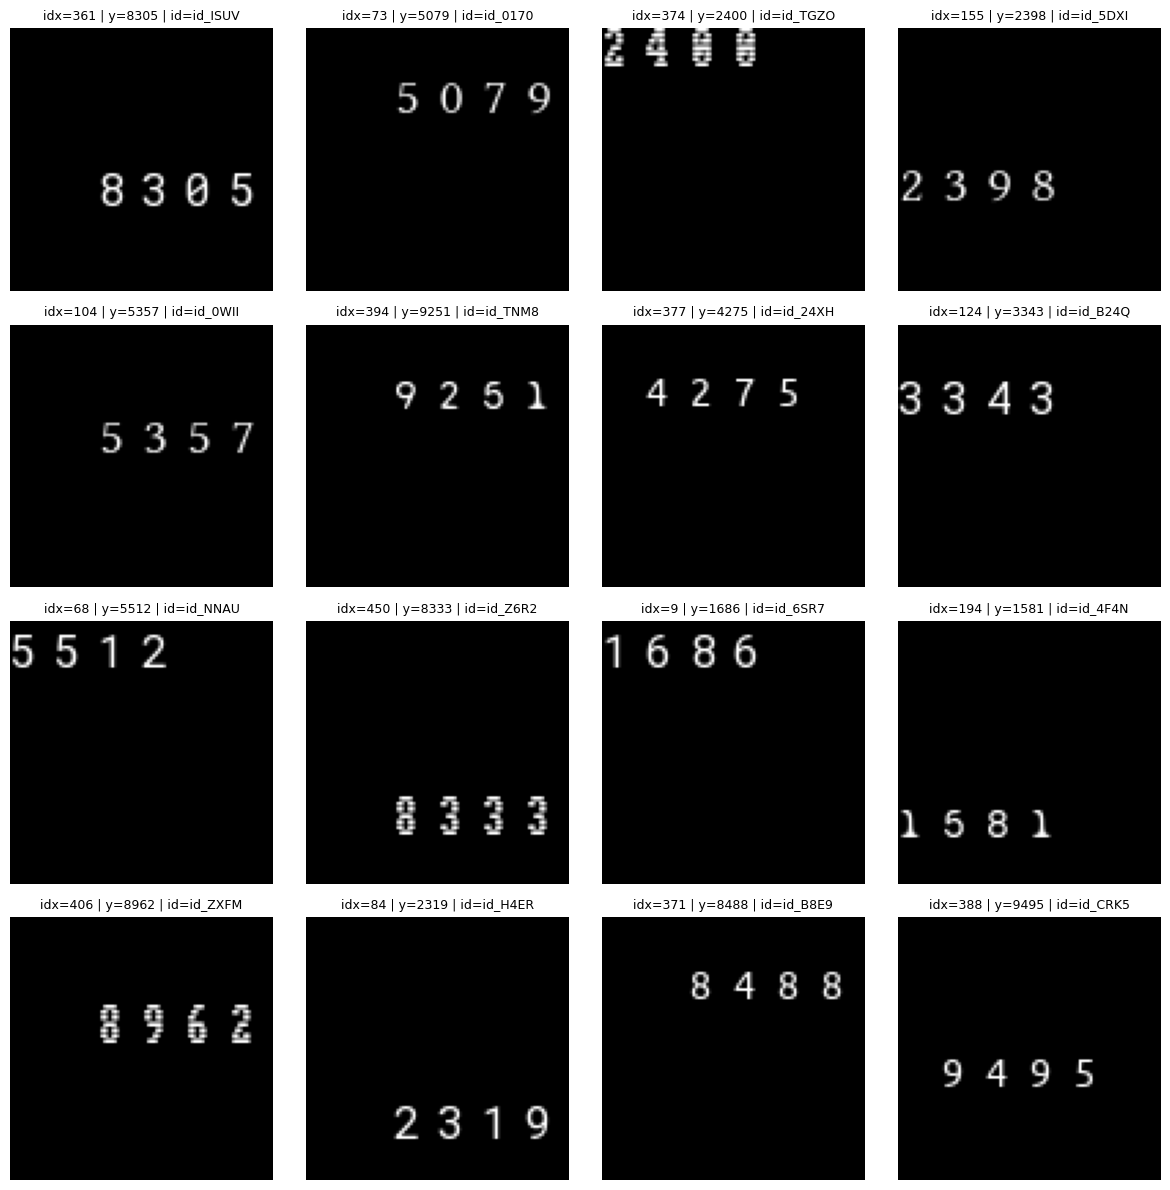

In [28]:
# ============================================================
# 3B. IMAGE PREVIEW MACHINE
# ============================================================

def pick_preview_indices(df, n=16, labels=None, random_pick=True):
    pool = df
    if labels is not None and "_label" in pool.columns:
        labels_str = [str(x) for x in labels]
        pool = pool[pool["_label"].astype(str).isin(labels_str)]
    n = min(n, len(pool))
    if n == 0:
        return []
    if random_pick:
        return pool.sample(n=n, random_state=SEED).index.tolist()
    return pool.head(n).index.tolist()

def preview_images():
    step("Step 3/9: Raw image preview")
    df = STATE["train_df"] if PREVIEW_SOURCE == "train" else STATE["test_df"]
    idxs = pick_preview_indices(df, PREVIEW_N, PREVIEW_LABELS, PREVIEW_RANDOM)
    images = []
    titles = []
    bad = []
    for idx in idxs:
        try:
            img = get_raw_image(df, idx)
            images.append(img)
            title = f"idx={idx}"
            if "_label" in df.columns:
                title += f" | y={df.loc[idx, '_label']}"
            if "_id" in df.columns:
                title += f" | id={df.loc[idx, '_id']}"
            titles.append(title)
        except Exception as e:
            bad.append((idx, repr(e)))
    if bad:
        print("Bad preview images:", bad[:5])
    show_grid(images, titles=titles, n=PREVIEW_N, figsize=(12, 12))

preview_images()

## 4. Mesin: Label EDA


Step 4/9: Label EDA


,count,pct
_label,,
1011,1,0.002
1016,1,0.002
1045,1,0.002
1061,1,0.002
110,1,0.002
...,...,...
9916,1,0.002
9932,1,0.002
9933,1,0.002


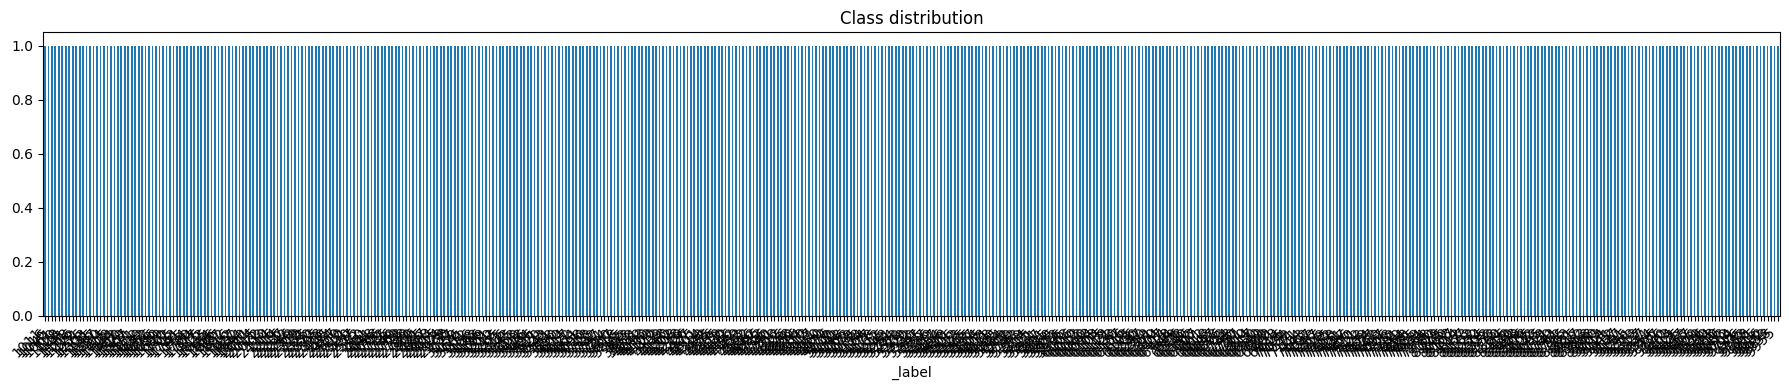

Imbalance ratio max/min: 1.00x

Examples per class:


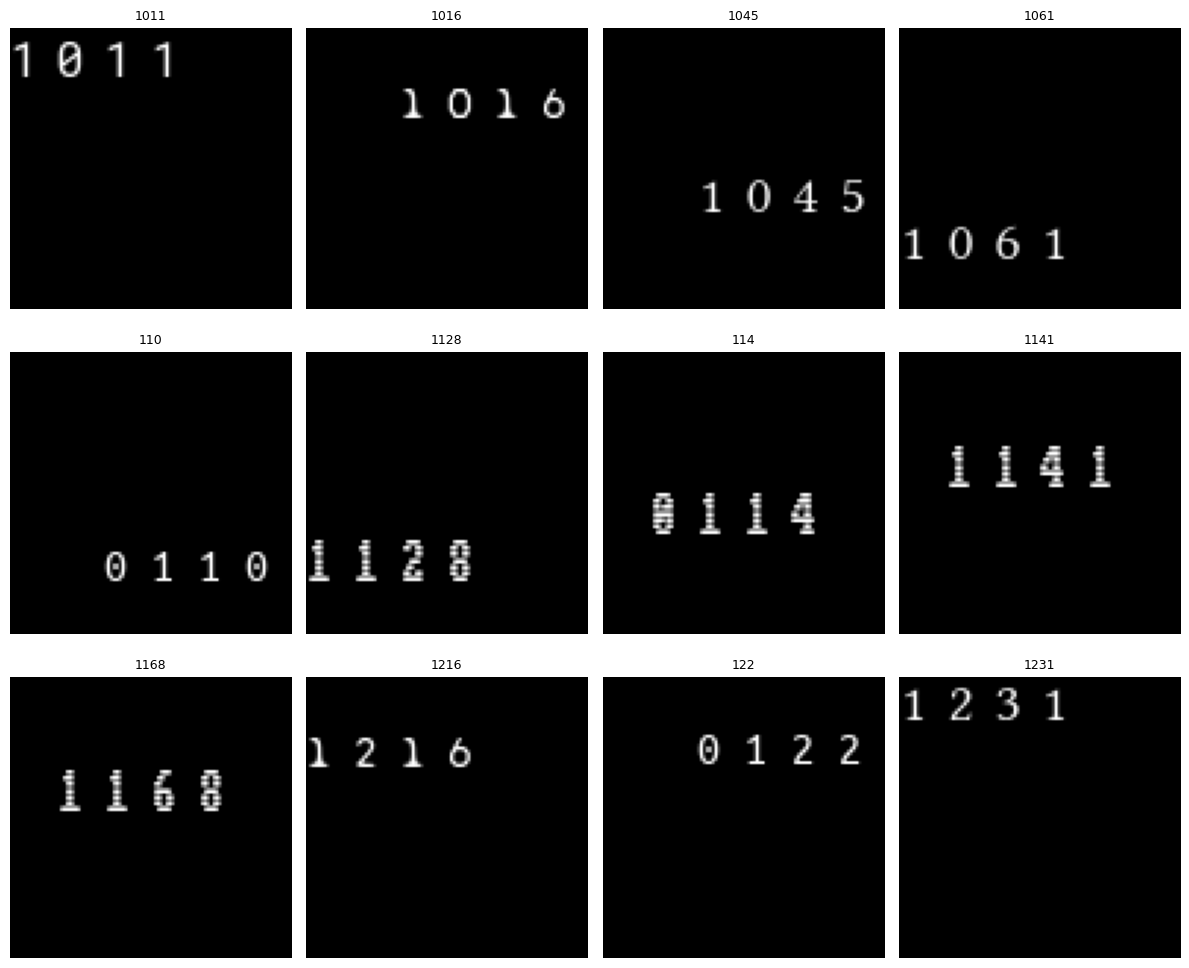

In [29]:
# ============================================================
# 4. LABEL EDA MACHINE
# ============================================================

def label_eda():
    step("Step 4/9: Label EDA")
    counts = STATE["label_counts"]
    assert counts is not None, "Run Step 1B first."
    counts = counts.sort_index()
    total = int(counts.sum())
    label_table = pd.DataFrame({
        "count": counts,
        "pct": counts / total,
    })
    display(label_table)
    plot_bar(counts, title="Class distribution", figsize=(max(8, min(18, len(counts) * 0.7)), 4))

    imbalance_ratio = float(counts.max() / max(counts.min(), 1))
    STATE["findings"]["imbalance_ratio"] = imbalance_ratio
    print(f"Imbalance ratio max/min: {imbalance_ratio:.2f}x")
    if imbalance_ratio >= 3:
        add_reco("Class imbalance detected: use macro_f1 / balanced_accuracy locally, and weighted CE or focal loss.")
    else:
        add_reco("Class distribution looks reasonably balanced: accuracy + CrossEntropy is fine as baseline.")

    # Sample a few examples per class for visual inspection.
    df = STATE["train_df"]
    images = []
    titles = []
    max_per_class = max(1, PREVIEW_ROWS // max(1, min(len(counts), 8)))
    for label in counts.index[:12]:
        part = df[df["_label"].astype(str) == str(label)].head(max_per_class)
        for idx in part.index:
            try:
                images.append(get_raw_image(df, idx))
                titles.append(str(label))
            except Exception:
                pass
    print("\nExamples per class:")
    show_grid(images, titles=titles, n=min(PREVIEW_ROWS, len(images)), figsize=(12, 10))

label_eda()

## 5A. Parameter: Image Health

In [30]:
# ============================================================
# 5A. IMAGE HEALTH PARAMETERS
# ============================================================

HEALTH_SAMPLE_N = 512
SHOW_PROBLEM_EXAMPLES = True
PROBLEM_EXAMPLE_N = 8

## 5B. Mesin: Image Health


Step 5/9: Image health EDA
sampled images: 500
bad/corrupt sampled images: 0

Numeric summary:


,count,mean,std,min,25%,50%,75%,max
h,500.0,96.000000,0.000000,96.000000,96.000000,96.000000,96.000000,96.000000
w,500.0,96.000000,0.000000,96.000000,96.000000,96.000000,96.000000,96.000000
aspect,500.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
brightness,500.0,3.461333,0.883252,2.185764,2.761149,3.084635,4.080105,5.834635
contrast,500.0,25.475817,3.056982,20.765474,23.044367,24.114093,28.041120,32.968322
blur,500.0,2800.736598,344.211584,1711.113281,2595.218316,2827.955636,3039.211390,3668.155211
edge_center_delta,500.0,3.221289,1.413598,0.079147,2.397367,3.146667,4.009383,7.605451


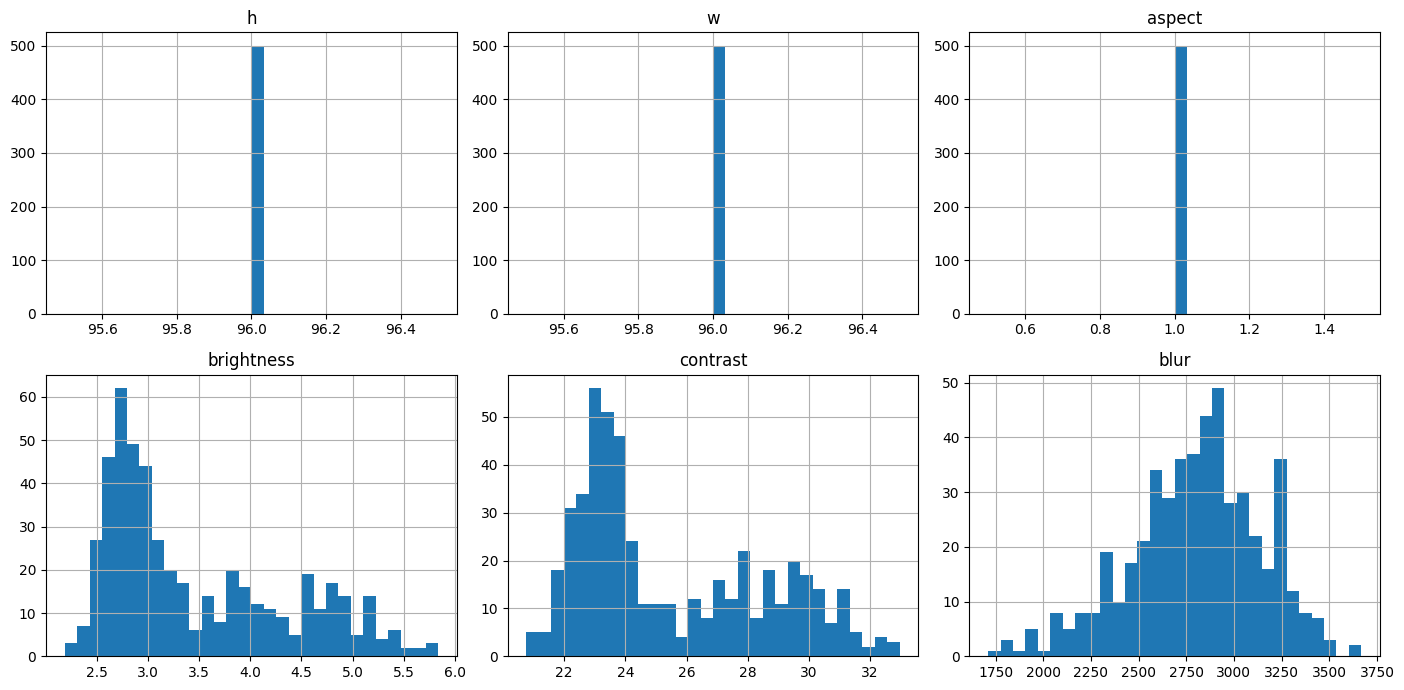


Problem examples: dark


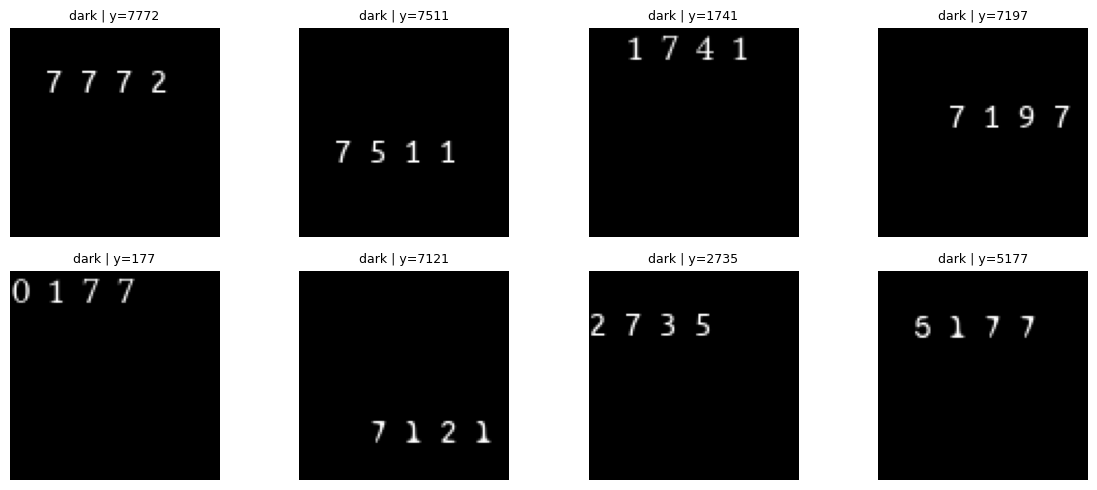


Problem examples: bright


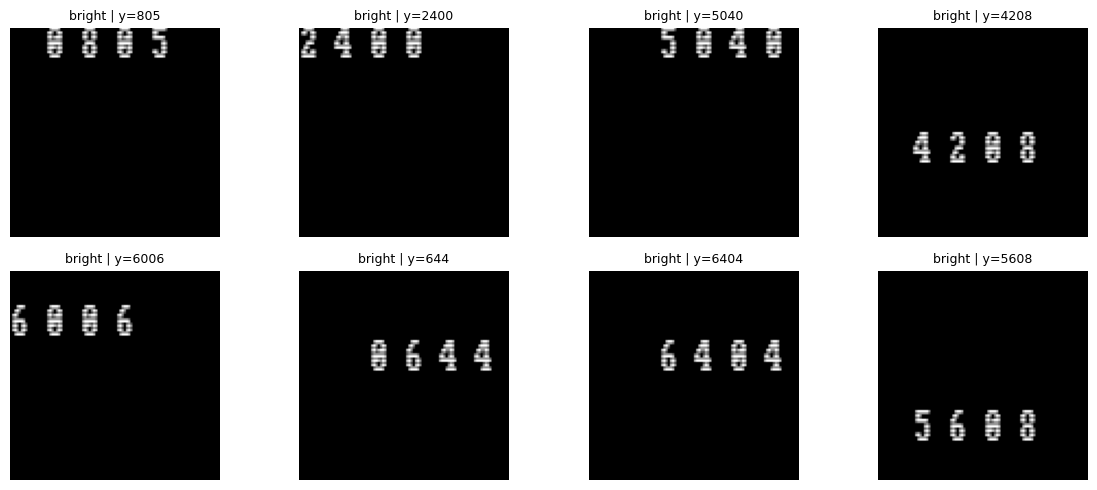


Problem examples: low_contrast


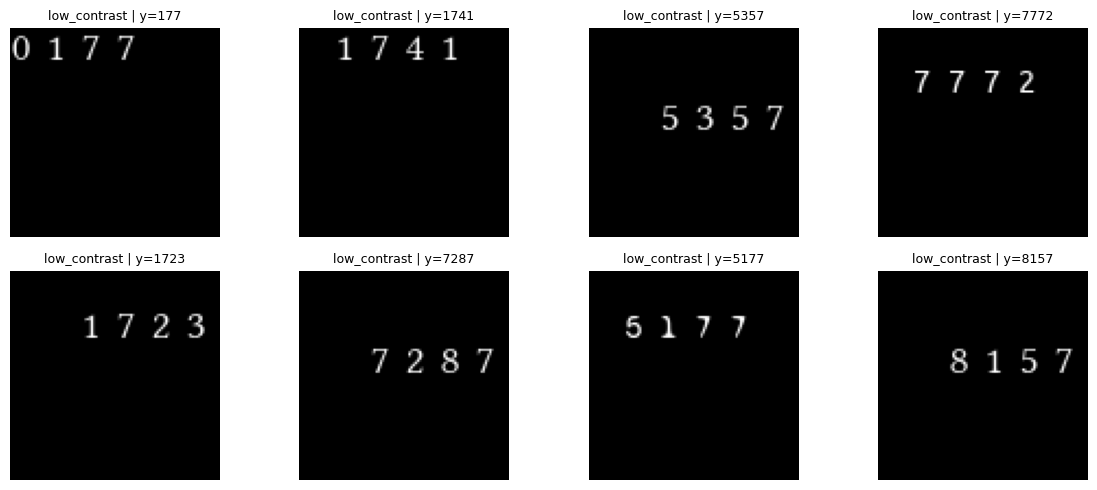


Problem examples: blurry


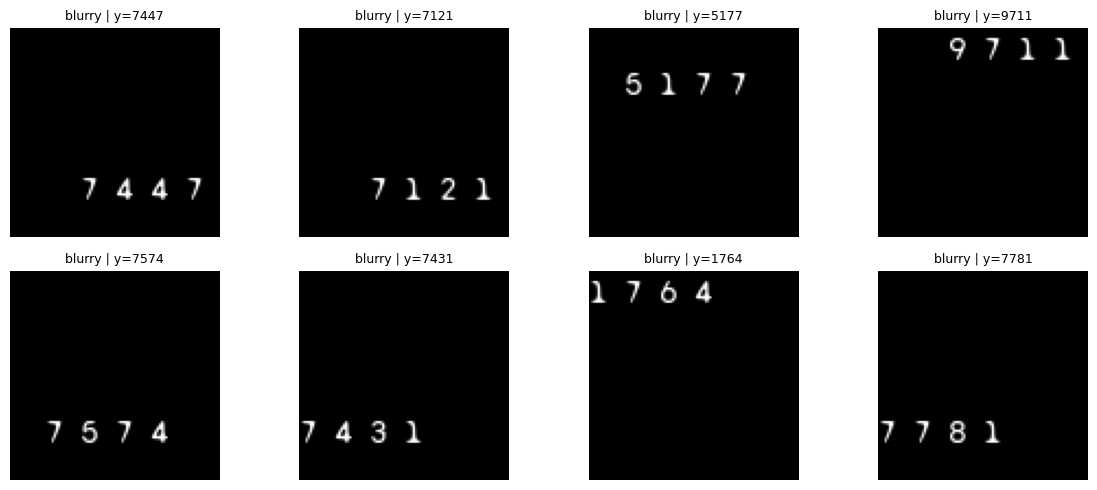

In [31]:
# ============================================================
# 5B. IMAGE HEALTH MACHINE
# ============================================================

def image_blur_score(gray):
    if CV2_AVAILABLE:
        return float(cv2.Laplacian(gray, cv2.CV_64F).var())
    gy, gx = np.gradient(gray.astype(float))
    return float(np.var(gx) + np.var(gy))

def edge_background_fraction(gray, margin=3):
    h, w = gray.shape[:2]
    margin = max(1, min(margin, h // 4, w // 4))
    border = np.concatenate([
        gray[:margin, :].ravel(),
        gray[-margin:, :].ravel(),
        gray[:, :margin].ravel(),
        gray[:, -margin:].ravel(),
    ])
    center = gray[margin:-margin, margin:-margin].ravel() if h > 2 * margin and w > 2 * margin else gray.ravel()
    return float(abs(border.mean() - center.mean()))

def image_health_eda():
    step("Step 5/9: Image health EDA")
    df = STATE["train_df"]
    n = min(HEALTH_SAMPLE_N, len(df))
    idxs = df.sample(n=n, random_state=SEED).index.tolist() if n < len(df) else list(df.index)
    rows = []
    bad = []
    for idx in idxs:
        try:
            img = get_raw_image(df, idx)
            h, w = img.shape[:2]
            gray = np.asarray(Image.fromarray(img).convert("L"))
            rows.append({
                "idx": int(idx),
                "id": df.loc[idx, "_id"] if "_id" in df.columns else idx,
                "label": df.loc[idx, "_label"] if "_label" in df.columns else None,
                "h": int(h),
                "w": int(w),
                "channels": int(img.shape[2]) if img.ndim == 3 else 1,
                "aspect": float(w / max(h, 1)),
                "brightness": float(gray.mean()),
                "contrast": float(gray.std()),
                "blur": image_blur_score(gray),
                "edge_center_delta": edge_background_fraction(gray),
            })
        except Exception as e:
            bad.append((idx, repr(e)))

    stats = pd.DataFrame(rows)
    STATE["image_stats"] = stats
    print("sampled images:", n)
    print("bad/corrupt sampled images:", len(bad))
    if bad:
        display(pd.DataFrame(bad[:20], columns=["idx", "error"]))

    print("\nNumeric summary:")
    display(stats[["h", "w", "aspect", "brightness", "contrast", "blur", "edge_center_delta"]].describe().T)

    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    for ax, col in zip(axes.ravel(), ["h", "w", "aspect", "brightness", "contrast", "blur"]):
        stats[col].hist(ax=ax, bins=30)
        ax.set_title(col)
    plt.tight_layout()
    plt.show()

    median_short_side = float(stats[["h", "w"]].min(axis=1).median()) if len(stats) else 0
    aspect_std = float(stats["aspect"].std()) if len(stats) else 0
    median_contrast = float(stats["contrast"].median()) if len(stats) else 0
    median_edge_delta = float(stats["edge_center_delta"].median()) if len(stats) else 0

    STATE["findings"]["median_short_side"] = median_short_side
    STATE["findings"]["aspect_std"] = aspect_std
    STATE["findings"]["median_contrast"] = median_contrast
    STATE["findings"]["median_edge_delta"] = median_edge_delta

    if LOADER_MODE == "csv_pixels" or median_short_side <= 64:
        add_reco("Images are tiny / csv_pixels: use SEGMENT_BLOCK='none'. Cropping/contour usually hurts.")
    if aspect_std > 0.35:
        add_reco("Aspect ratio varies: prefer PREPROCESS_BLOCK='resize_pad_rgb' instead of direct resize.")
    if median_contrast < 35:
        add_reco("Low contrast images: try PREPROCESS_BLOCK='clahe_gray' for grayscale/document-like data.")
    if median_edge_delta > 20 and median_short_side > 64:
        add_reco("Background/foreground difference seems visible: try contour_crop or threshold_crop preview.")

    if SHOW_PROBLEM_EXAMPLES and len(stats):
        problem_sets = [
            ("dark", stats.sort_values("brightness").head(PROBLEM_EXAMPLE_N)),
            ("bright", stats.sort_values("brightness", ascending=False).head(PROBLEM_EXAMPLE_N)),
            ("low_contrast", stats.sort_values("contrast").head(PROBLEM_EXAMPLE_N)),
            ("blurry", stats.sort_values("blur").head(PROBLEM_EXAMPLE_N)),
        ]
        for name, part in problem_sets:
            images, titles = [], []
            for idx in part["idx"].tolist():
                try:
                    images.append(get_raw_image(df, idx))
                    titles.append(f"{name} | y={df.loc[idx, '_label']}")
                except Exception:
                    pass
            print(f"\nProblem examples: {name}")
            show_grid(images, titles=titles, n=min(PROBLEM_EXAMPLE_N, len(images)), figsize=(12, 5))

image_health_eda()

## 6. Mesin: Pixel CSV EDA

In [32]:
# ============================================================
# 6. PIXEL CSV EDA MACHINE
# ============================================================

def pixel_csv_eda():
    step("Step 6/9: Pixel CSV EDA")
    if LOADER_MODE != "csv_pixels":
        print("Skipping: LOADER_MODE is not csv_pixels.")
        return
    df = STATE["train_df"]
    pixel_cols = df.iloc[0]["_pixel_cols"]
    X = df[pixel_cols].to_numpy(dtype=np.float32)
    if X.max() <= 1.0:
        X_disp = X * 255.0
    else:
        X_disp = X
    shape = PIXEL_SHAPE
    mean_img = X_disp.mean(axis=0).reshape(shape)
    std_img = X_disp.std(axis=0).reshape(shape)

    print("Pixel matrix:", X.shape)
    print("Mean active pixels per image:", float((X_disp > 0).sum(axis=1).mean()))
    print("All-zero images:", int(((X_disp > 0).sum(axis=1) == 0).sum()))

    mean_show = mean_img.squeeze()
    std_show = std_img.squeeze()
    show_grid([mean_show, std_show], titles=["mean image", "std image"], n=2, figsize=(6, 3), cmap="gray")

    labels = df["_label"].astype(str)
    classes = sorted(labels.unique().tolist())
    images, titles = [], []
    for cls in classes[:12]:
        idx = labels[labels == cls].index
        if len(idx) == 0:
            continue
        cls_mean = X_disp[idx].mean(axis=0).reshape(shape).squeeze()
        images.append(cls_mean)
        titles.append(f"mean: {cls}")
    print("Mean image per class:")
    show_grid(images, titles=titles, n=len(images), figsize=(12, 8), cmap="gray")

    add_reco("For csv_pixels baseline: LOADER_MODE='csv_pixels', SEGMENT_BLOCK='none', PREPROCESS_BLOCK='grayscale'.")
    add_reco(f"For this pixel shape, start IMG_SIZE={shape[0]} if square; avoid unnecessary upscaling for first run.")

pixel_csv_eda()


Step 6/9: Pixel CSV EDA
Skipping: LOADER_MODE is not csv_pixels.


## 7A. Parameter: Segmentasi dan Preprocess Preview

In [33]:
# ============================================================
# 7A. SEGMENT / PREPROCESS PREVIEW PARAMETERS
# ============================================================

describe_options("Available EDA_SEGMENT_BLOCK", {
    "none": "use full original image",
    "center_crop": "crop center square at original resolution",
    "contour_crop": "crop largest contour/object at original resolution",
    "threshold_crop": "threshold foreground then crop active area",
    "tile_2x2": "split image into 4 tiles for inspection",
    "tile_3x3": "split image into 9 tiles for inspection",
})

describe_options("Available EDA_PREPROCESS_BLOCK", {
    "resize_rgb": "direct resize to EDA_IMG_SIZE",
    "resize_pad_rgb": "preserve aspect ratio and pad to square",
    "grayscale": "convert to grayscale then resize",
    "clahe_gray": "grayscale + CLAHE contrast enhancement",
    "threshold_binary": "grayscale + binary threshold",
})

EDA_SEGMENT_BLOCK = "none"
EDA_PREPROCESS_BLOCK = "grayscale" if LOADER_MODE == "csv_pixels" else "resize_pad_rgb"
EDA_IMG_SIZE = PIXEL_SHAPE[0] if LOADER_MODE == "csv_pixels" and PIXEL_SHAPE is not None else 128
EDA_PREVIEW_N = 8


Available EDA_SEGMENT_BLOCK
- none: use full original image
- center_crop: crop center square at original resolution
- contour_crop: crop largest contour/object at original resolution
- threshold_crop: threshold foreground then crop active area
- tile_2x2: split image into 4 tiles for inspection
- tile_3x3: split image into 9 tiles for inspection

Available EDA_PREPROCESS_BLOCK
- resize_rgb: direct resize to EDA_IMG_SIZE
- resize_pad_rgb: preserve aspect ratio and pad to square
- grayscale: convert to grayscale then resize
- clahe_gray: grayscale + CLAHE contrast enhancement
- threshold_binary: grayscale + binary threshold


## 7B. Mesin: Segmentasi dan Preprocess Preview


Step 7/9: Segment + preprocess preview
EDA_SEGMENT_BLOCK: none
EDA_PREPROCESS_BLOCK: resize_pad_rgb | EDA_IMG_SIZE: 128

Original:


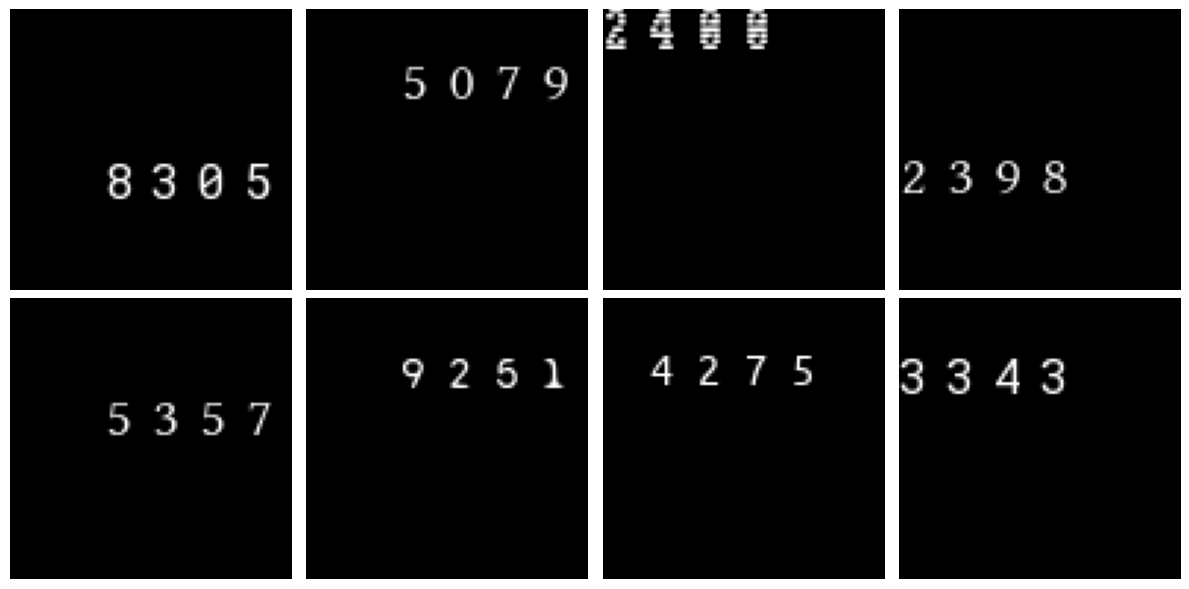


Segment output:


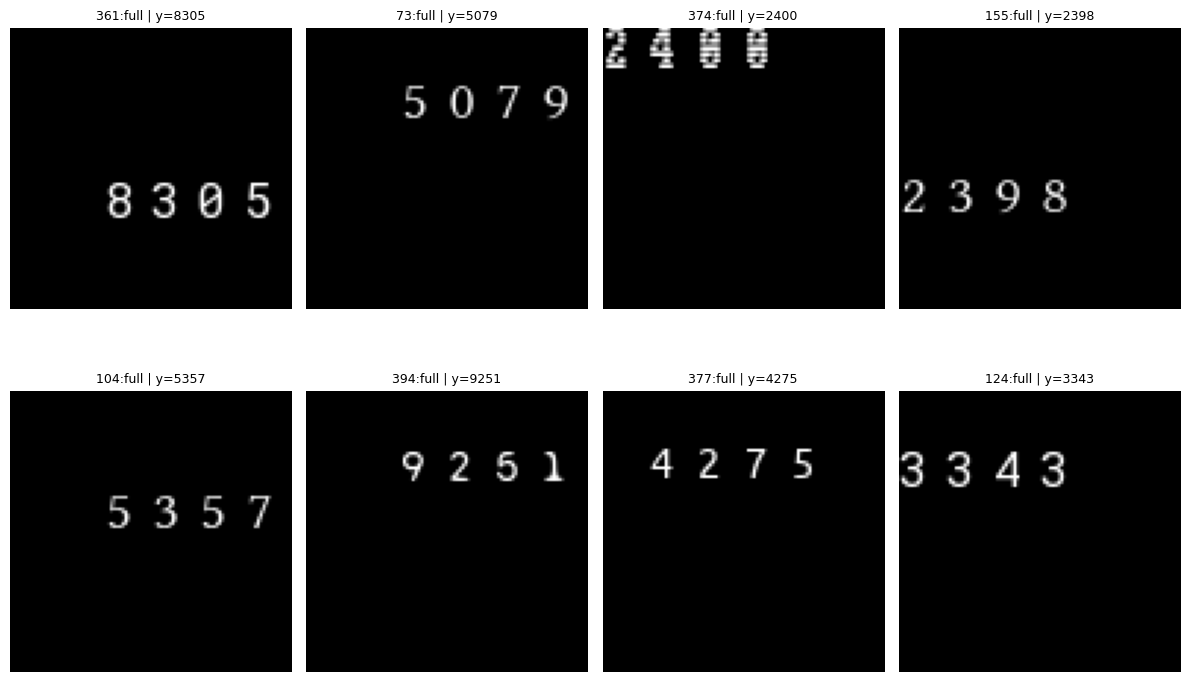


Preprocess output:


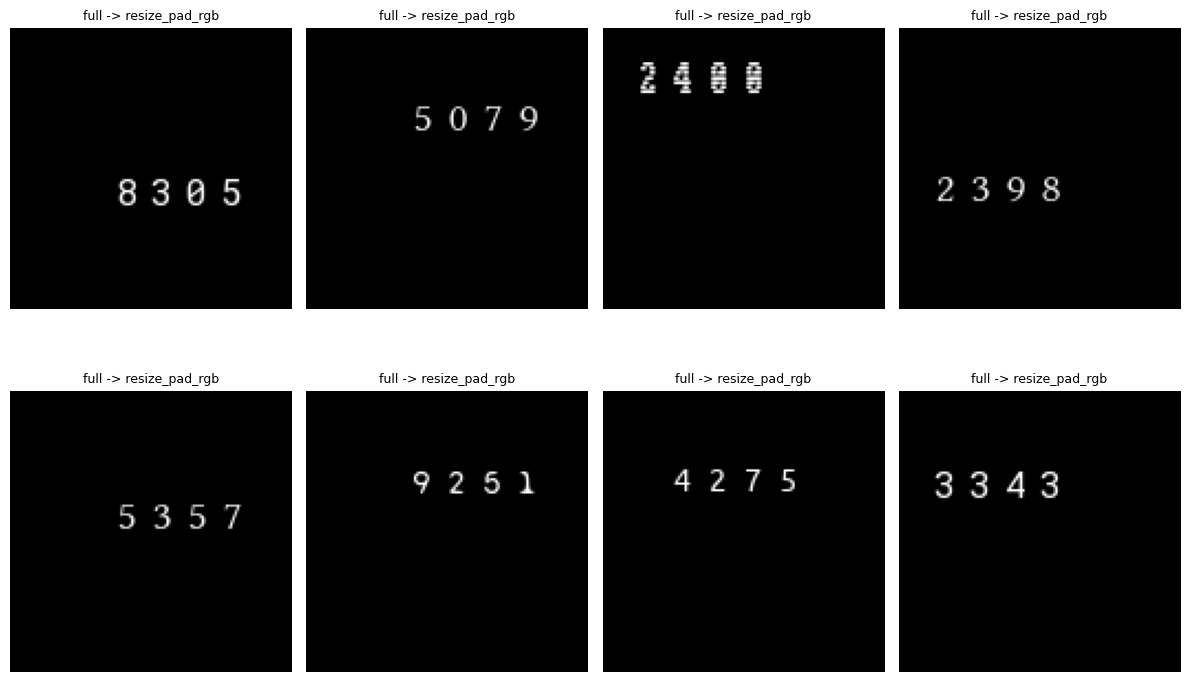

In [34]:
# ============================================================
# 7B. SEGMENT / PREPROCESS PREVIEW MACHINE
# ============================================================

def crop_box_safe(img, x, y, w, h, pad=4):
    H, W = img.shape[:2]
    x0 = max(0, x - pad)
    y0 = max(0, y - pad)
    x1 = min(W, x + w + pad)
    y1 = min(H, y + h + pad)
    if x1 <= x0 or y1 <= y0:
        return img
    return img[y0:y1, x0:x1]

def segment_tile(img, grid):
    h, w = img.shape[:2]
    crops, names = [], []
    for r in range(grid):
        for c in range(grid):
            y0 = int(round(r * h / grid))
            y1 = int(round((r + 1) * h / grid))
            x0 = int(round(c * w / grid))
            x1 = int(round((c + 1) * w / grid))
            crops.append(img[y0:y1, x0:x1])
            names.append(f"tile_{r}_{c}")
    return crops, names

def segment_one(img, block=None):
    block = block or EDA_SEGMENT_BLOCK
    if block == "none":
        return [img], ["full"]
    if block == "center_crop":
        h, w = img.shape[:2]
        side = min(h, w)
        y = (h - side) // 2
        x = (w - side) // 2
        return [img[y:y + side, x:x + side]], ["center"]
    if block == "threshold_crop":
        gray = np.asarray(Image.fromarray(img).convert("L"))
        if CV2_AVAILABLE:
            blur = cv2.GaussianBlur(gray, (5, 5), 0)
            _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
            if th.mean() > 127:
                th = 255 - th
            coords = cv2.findNonZero(th)
            if coords is None:
                return [img], ["fallback_full"]
            x, y, w, h = cv2.boundingRect(coords)
            return [crop_box_safe(img, x, y, w, h)], ["threshold_crop"]
        mask = gray < gray.mean()
        ys, xs = np.where(mask)
        if len(xs) == 0:
            return [img], ["fallback_full"]
        return [crop_box_safe(img, xs.min(), ys.min(), xs.max() - xs.min() + 1, ys.max() - ys.min() + 1)], ["threshold_crop"]
    if block == "contour_crop":
        if not CV2_AVAILABLE:
            return segment_one(img, "threshold_crop")
        gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        _, th = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        if th.mean() > 127:
            th = 255 - th
        contours, _ = cv2.findContours(th, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            return [img], ["fallback_full"]
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        if area < 0.01 * img.shape[0] * img.shape[1]:
            return [img], ["fallback_full"]
        x, y, w, h = cv2.boundingRect(cnt)
        return [crop_box_safe(img, x, y, w, h)], ["contour_crop"]
    if block == "tile_2x2":
        return segment_tile(img, 2)
    if block == "tile_3x3":
        return segment_tile(img, 3)
    raise ValueError(f"Unknown EDA_SEGMENT_BLOCK: {block}")

def resize_pad_pil(img, size=128, fill=0):
    pil = Image.fromarray(img).convert("RGB")
    pil.thumbnail((size, size), Image.Resampling.BILINEAR)
    canvas = Image.new("RGB", (size, size), (fill, fill, fill))
    x = (size - pil.width) // 2
    y = (size - pil.height) // 2
    canvas.paste(pil, (x, y))
    return np.asarray(canvas)

def preprocess_preview_one(img, block=None, size=None):
    block = block or EDA_PREPROCESS_BLOCK
    size = int(size or EDA_IMG_SIZE)
    img = np.asarray(Image.fromarray(img).convert("RGB"))
    if block == "resize_rgb":
        out = np.asarray(Image.fromarray(img).resize((size, size), Image.Resampling.BILINEAR))
    elif block == "resize_pad_rgb":
        out = resize_pad_pil(img, size=size)
    elif block == "grayscale":
        out = np.asarray(Image.fromarray(img).convert("L").resize((size, size), Image.Resampling.BILINEAR))
    elif block == "clahe_gray":
        gray = np.asarray(Image.fromarray(img).convert("L"))
        if CV2_AVAILABLE:
            gray = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)).apply(gray)
        out = np.asarray(Image.fromarray(gray).resize((size, size), Image.Resampling.BILINEAR))
    elif block == "threshold_binary":
        gray = np.asarray(Image.fromarray(img).convert("L"))
        if CV2_AVAILABLE:
            _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        else:
            th = (gray > gray.mean()).astype(np.uint8) * 255
        out = np.asarray(Image.fromarray(th).resize((size, size), Image.Resampling.NEAREST))
    else:
        raise ValueError(f"Unknown EDA_PREPROCESS_BLOCK: {block}")
    return out.astype(np.uint8)

def segment_preprocess_preview():
    step("Step 7/9: Segment + preprocess preview")
    df = STATE["train_df"]
    idxs = pick_preview_indices(df, EDA_PREVIEW_N, labels=None, random_pick=True)
    originals, segmented, processed = [], [], []
    seg_titles, proc_titles = [], []
    for idx in idxs:
        img = get_raw_image(df, idx)
        crops, names = segment_one(img)
        originals.append(img)
        for crop, name in zip(crops[:3], names[:3]):
            segmented.append(crop)
            segmented_label = f"{idx}:{name}"
            if "_label" in df.columns:
                segmented_label += f" | y={df.loc[idx, '_label']}"
            seg_titles.append(segmented_label)
            processed.append(preprocess_preview_one(crop))
            proc_titles.append(f"{name} -> {EDA_PREPROCESS_BLOCK}")

    print("EDA_SEGMENT_BLOCK:", EDA_SEGMENT_BLOCK)
    print("EDA_PREPROCESS_BLOCK:", EDA_PREPROCESS_BLOCK, "| EDA_IMG_SIZE:", EDA_IMG_SIZE)
    if LOADER_MODE == "csv_pixels" and EDA_SEGMENT_BLOCK != "none":
        print("WARNING: csv_pixels usually should use EDA_SEGMENT_BLOCK='none'.")
    if EDA_SEGMENT_BLOCK.startswith("tile"):
        print("WARNING: tiling is only sensible when class signal is spread across the image.")
    print("\nOriginal:")
    show_grid(originals, n=len(originals), figsize=(12, 6))
    print("\nSegment output:")
    show_grid(segmented, titles=seg_titles, n=min(16, len(segmented)), figsize=(12, 8))
    print("\nPreprocess output:")
    show_grid(processed, titles=proc_titles, n=min(16, len(processed)), figsize=(12, 8), cmap="gray")

segment_preprocess_preview()

## 8. Mesin: Submission dan Leakage Sanity

In [35]:
# ============================================================
# 8. SUBMISSION / LEAKAGE SANITY MACHINE
# ============================================================

def submission_leakage_sanity():
    step("Step 8/9: Submission and leakage sanity")
    train_df = STATE["train_df"]
    test_df = STATE["test_df"]
    sample = STATE["sample_submission"]

    if sample is None:
        print("No sample_submission found. You must inspect competition submission format manually.")
        add_reco("No sample_submission detected: make sure final CSV columns and row order match Kaggle format.")
    else:
        print("sample_submission shape:", sample.shape)
        print("sample columns:", list(sample.columns))
        print("test rows == sample rows:", len(test_df) == len(sample))
        display(sample.head())
        sample_ids = sample.iloc[:, 0].astype(str).tolist()
        test_ids = test_df["_id"].astype(str).tolist() if "_id" in test_df.columns else []
        exact = sample_ids == test_ids
        print("sample first column matches test _id order:", exact)
        if not exact:
            sample_set = set(sample_ids)
            test_set = set(test_ids)
            print("id set equal:", sample_set == test_set)
            print("sample id head/tail:", sample_ids[:3], sample_ids[-3:])
            print("test _id head/tail:", test_ids[:3], test_ids[-3:])
            add_reco("Submission ID order differs from test _id. Fix ID_COL or map predictions by sample_submission ID.")

    if LOADER_MODE in ["csv_path", "folder_class"]:
        train_names = set(Path(p).name for p in train_df["_image_path"].astype(str))
        test_names = set(Path(p).name for p in test_df["_image_path"].astype(str))
        overlap = sorted(train_names & test_names)
        print("train/test filename overlap:", len(overlap))
        if overlap[:10]:
            print("overlap examples:", overlap[:10])
        if overlap:
            add_reco("Train/test filename overlap detected. Check if duplicated images or leakage exist.")

    if LOADER_MODE == "csv_pixels":
        train_pixel_cols = list(train_df.iloc[0]["_pixel_cols"])
        test_pixel_cols = list(test_df.iloc[0]["_pixel_cols"])
        print("train/test pixel columns equal:", train_pixel_cols == test_pixel_cols)
        if train_pixel_cols != test_pixel_cols:
            add_reco("Train/test pixel columns differ. Align columns before training.")

submission_leakage_sanity()


Step 8/9: Submission and leakage sanity
sample_submission shape: (500, 2)
sample columns: ['image_id', 'image_pair']
test rows == sample rows: True


,image_id,image_pair
0,id_DCBL,id_AAAA
1,id_YUKN,id_AAAA
2,id_25WM,id_AAAA
3,id_6ESM,id_AAAA
4,id_L51F,id_AAAA


sample first column matches test _id order: True
train/test filename overlap: 0


## 9. Mesin: Final EDA Recommendations

In [36]:
# ============================================================
# 9. FINAL EDA RECOMMENDATIONS
# ============================================================

def choose_starter_config():
    findings = STATE["findings"]
    segment = "none"
    preprocess = "resize_pad_rgb"
    img_size = 128
    color = "rgb"
    eval_block = "accuracy_eval"
    loss_block = "ce"

    if LOADER_MODE == "csv_pixels":
        segment = "none"
        preprocess = "grayscale"
        color = "grayscale"
        if PIXEL_SHAPE is not None and len(PIXEL_SHAPE) >= 2 and PIXEL_SHAPE[0] == PIXEL_SHAPE[1]:
            img_size = int(PIXEL_SHAPE[0])
    else:
        median_short = findings.get("median_short_side", 128)
        aspect_std = findings.get("aspect_std", 0)
        contrast = findings.get("median_contrast", 50)
        edge_delta = findings.get("median_edge_delta", 0)
        if median_short <= 64:
            segment = "none"
            img_size = int(max(32, median_short))
        if aspect_std > 0.35:
            preprocess = "resize_pad_rgb"
        if contrast < 35:
            preprocess = "clahe_gray"
            color = "grayscale"
        if edge_delta > 20 and median_short > 64:
            segment = "contour_crop"

    imbalance = findings.get("imbalance_ratio", 1)
    if imbalance >= 3:
        eval_block = "macro_f1_eval"
        loss_block = "weighted_ce"

    return {
        "SEGMENT_BLOCK": segment,
        "PREPROCESS_BLOCK": preprocess,
        "IMG_SIZE": img_size,
        "COLOR_MODE": color,
        "AUGMENT_BLOCK": "light_aug",
        "MODEL_BLOCK": "small_cnn",
        "EVAL_BLOCK": eval_block,
        "LOSS_BLOCK": loss_block,
    }

def final_recommendations():
    step("Step 9/9: Final EDA recommendations")
    config = choose_starter_config()
    print("Recommended starter config for cv_lego_god.ipynb:\n")
    for k, v in config.items():
        print(f"{k} = {repr(v)}")

    print("\nWhy / notes:")
    for i, rec in enumerate(STATE["recommendations"], 1):
        print(f"{i}. {rec}")

    print("\nCopy-paste block:")
    print("# ---- paste into cv_lego_god.ipynb parameter cells ----")
    for k, v in config.items():
        print(f"{k} = {repr(v)}")

    print("\nExperiment order:")
    print("1. FAST_DEBUG=True first, create a valid submission_debug.csv.")
    print("2. FAST_DEBUG=False, run safe baseline with this config.")
    print("3. Only then try one change at a time: crop OR preprocess OR model OR img_size.")

final_recommendations()


Step 9/9: Final EDA recommendations
Recommended starter config for cv_lego_god.ipynb:

SEGMENT_BLOCK = 'none'
PREPROCESS_BLOCK = 'clahe_gray'
IMG_SIZE = 128
COLOR_MODE = 'grayscale'
AUGMENT_BLOCK = 'light_aug'
MODEL_BLOCK = 'small_cnn'
EVAL_BLOCK = 'accuracy_eval'
LOSS_BLOCK = 'ce'

Why / notes:
1. Class distribution looks reasonably balanced: accuracy + CrossEntropy is fine as baseline.
2. Low contrast images: try PREPROCESS_BLOCK='clahe_gray' for grayscale/document-like data.

Copy-paste block:
# ---- paste into cv_lego_god.ipynb parameter cells ----
SEGMENT_BLOCK = 'none'
PREPROCESS_BLOCK = 'clahe_gray'
IMG_SIZE = 128
COLOR_MODE = 'grayscale'
AUGMENT_BLOCK = 'light_aug'
MODEL_BLOCK = 'small_cnn'
EVAL_BLOCK = 'accuracy_eval'
LOSS_BLOCK = 'ce'

Experiment order:
1. FAST_DEBUG=True first, create a valid submission_debug.csv.
2. FAST_DEBUG=False, run safe baseline with this config.
3. Only then try one change at a time: crop OR preprocess OR model OR img_size.


## Final Notes

EDA ini tidak memilih model terbaik. Dia cuma membantu lu mengambil keputusan awal:

- loader mana yang benar
- dataset ini gambar file atau pixel CSV
- label imbalance atau tidak
- gambar terlalu kecil / background besar / low contrast
- segmentasi aman atau sebaiknya jangan
- submission format rawan mismatch atau aman

Setelah selesai, pindah ke `cv_lego_god.ipynb` dan pakai rekomendasi Step 9 sebagai starter config.